In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as  plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler , MinMaxScaler , LabelEncoder 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

In [11]:
HR = pd.read_csv(r"C:\Users\Suraj\Desktop\Heart Attack\heart.csv")

# Cleaning & Preprocessing 

In [12]:
#HR.dtypes

In [13]:
#HR.isnull().sum()

In [14]:
#HR.duplicated().sum()

In [15]:
HR.drop_duplicates(inplace=True)

In [16]:
#HR.duplicated().sum()

In [17]:
#for col in HR.columns:
 #   sns.boxplot(HR[col])
  #  plt.show()

# IQR Method

In [18]:
HR1 = HR.copy()

In [19]:
for col in HR1.columns:
    Q1 =  HR1[col].quantile(0.25)
    Q3 =  HR1[col].quantile(0.75)
    IQR = Q3-Q1
    upper_fence = Q3  +  (IQR*1.5)
    lower_fence = Q1  -  (IQR*1.5)
    HR1 = HR1[HR1[col].between(lower_fence,upper_fence)]
    

In [20]:
HR1.shape

(228, 14)

In [21]:
HR.shape

(302, 14)

In [22]:
228/302

0.7549668874172185

# Zscore Method 

In [23]:
HR2 =  HR.copy()

In [24]:
for col in HR2.columns:
    STD = StandardScaler()
    HR2[col+'STD'] =  STD.fit_transform(HR2[[col]])
    HR2 =  HR2[HR2[col+'STD'].between(-3,3)]
    HR2.drop(col+'STD',axis=1,inplace=True)

In [25]:
HR.shape

(302, 14)

In [26]:
HR2.shape

(287, 14)

In [27]:
287/302

0.9503311258278145

In [28]:
HR3 = HR.copy()

In [29]:
for col in HR3.columns:
    STD = StandardScaler()
    HR3[col+'STD'] =  STD.fit_transform(HR3[[col]])

In [30]:
HR3.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cholSTD,fbsSTD,restecgSTD,thalachSTD,exangSTD,oldpeakSTD,slopeSTD,caSTD,thalSTD,targetSTD
0,63,1,3,145,233,1,0,150,0,2.3,...,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,0.917313


In [31]:
HR3[HR3['cholSTD'].between(-3,3)]['cholSTD'].max()

2.8547797894216345

In [32]:
HR2.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


<Axes: >

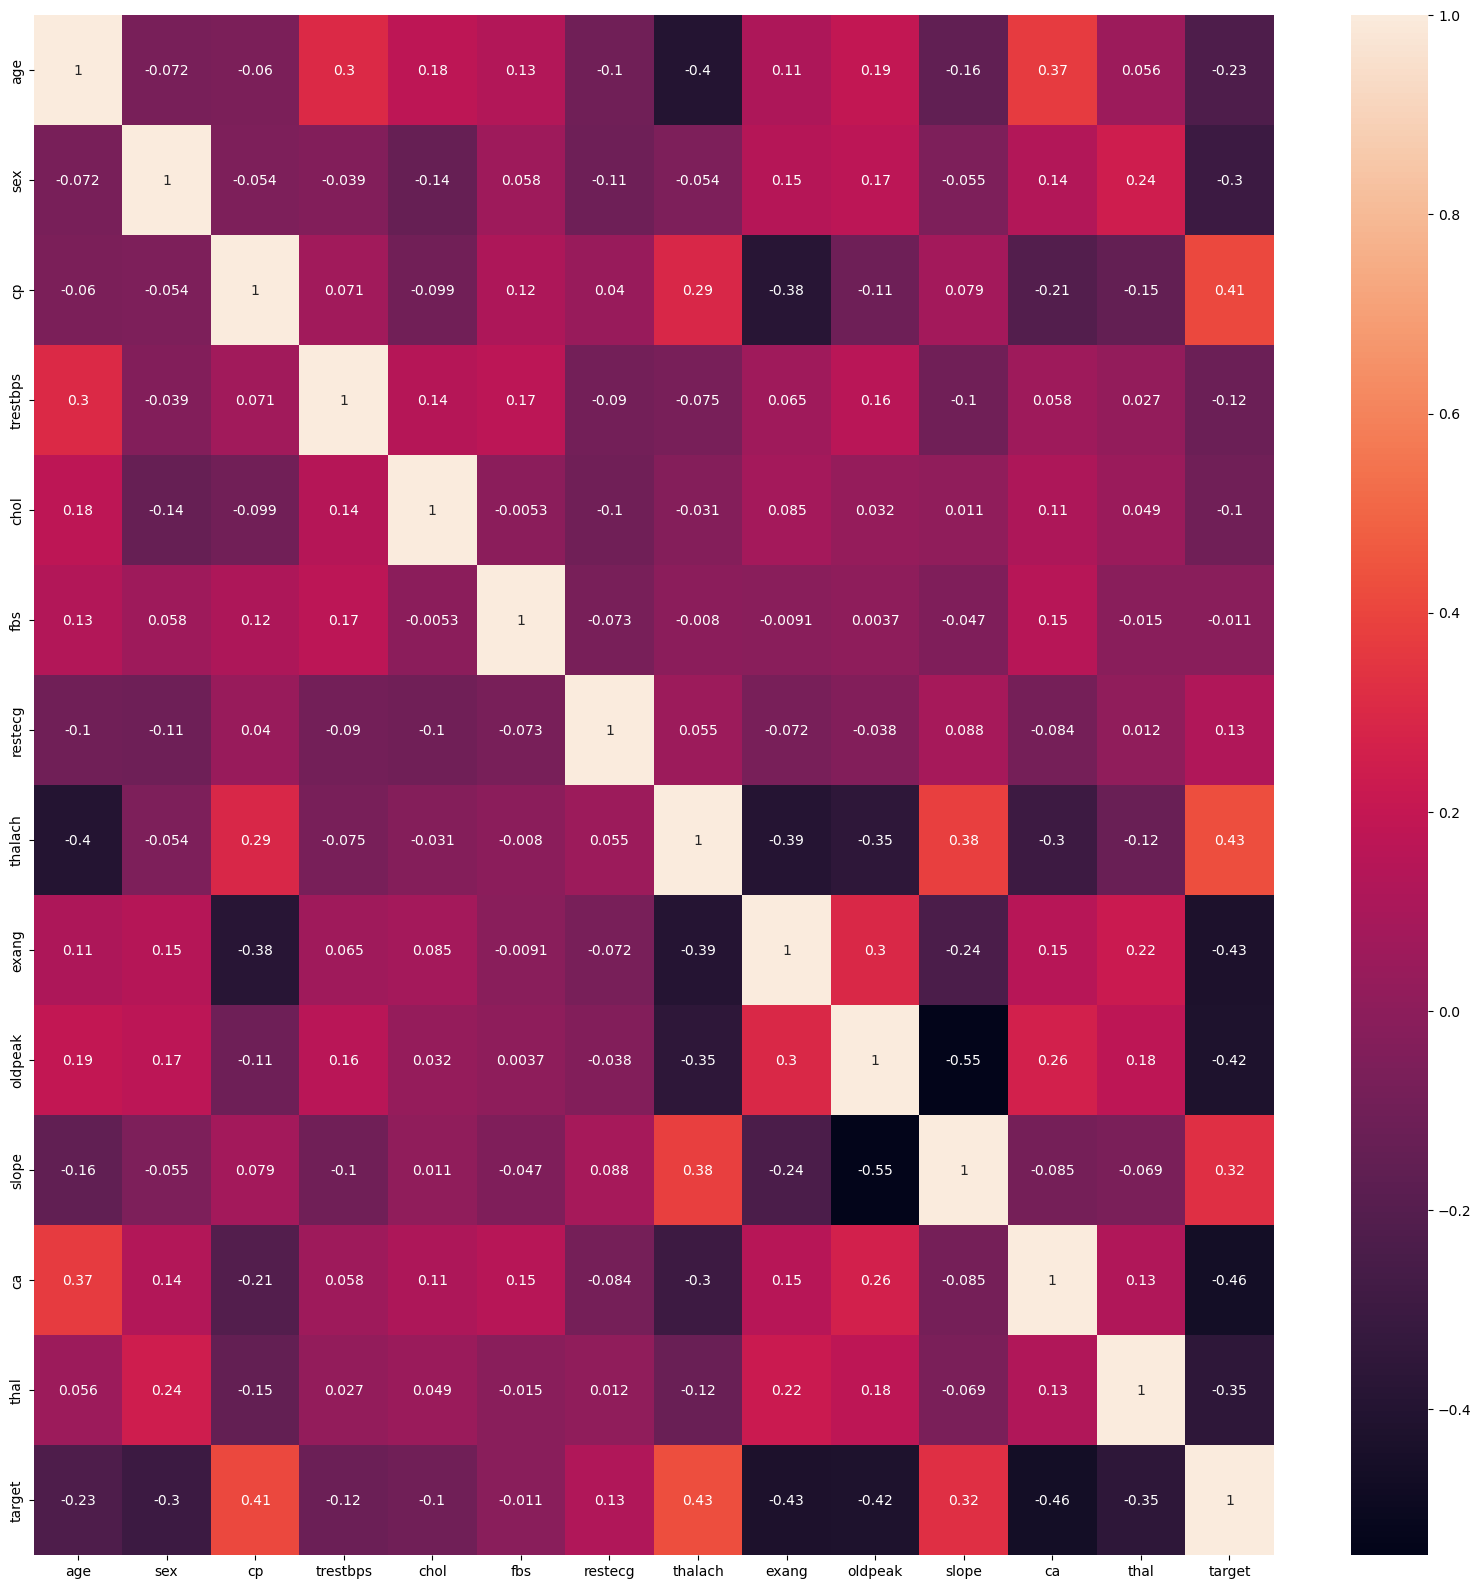

In [33]:
plt.figure(figsize=(20,20))
sns.heatmap(HR2.corr() , annot = True)

In [34]:
x=HR2.drop('target',axis=1)
y=HR2.target

In [35]:
std =  StandardScaler()
norm = MinMaxScaler()
x_std =  std.fit_transform(x)
x_norm = norm.fit_transform(x)

In [36]:
xtrain,xtest,ytrain,ytest = train_test_split(x_norm,y,test_size=0.25)

# Model 

In [37]:
LR = LogisticRegression()

In [38]:
LR.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Evaluation 

Accuracy |

In [39]:
LR.score(xtrain,ytrain)

0.8651162790697674

In [40]:
LR.score(xtest,ytest)

0.8472222222222222

In [41]:
pred =  LR.predict(xtest)

In [42]:
pred

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1])

In [43]:
ytest.values

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1])

In [44]:
from sklearn.metrics import classification_report

In [45]:
print(classification_report(ytest,pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81        32
           1       0.81      0.95      0.87        40

    accuracy                           0.85        72
   macro avg       0.86      0.83      0.84        72
weighted avg       0.86      0.85      0.84        72



In [46]:
x.shape

(287, 13)

# Deployment 

In [47]:
LR.predict([[0.5,0.7,0.3,0.2,0.5,0.7,0.6,0.8,0.9,0.2,0.8,2,0.8]])

array([0])

In [48]:
x.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [49]:
LR.predict_proba([[0.5,0.7,0.3,0.2,0.5,0.7,0.6,0.8,0.9,0.2,0.8,2,0.8]])

array([[0.96543542, 0.03456458]])

In [50]:
LR

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
import joblib

In [54]:
joblib.dump(LR,"Heart_attack_prediction.pkl")

['Heart_attack_prediction.pkl']

In [55]:
pwd

'C:\\Users\\Suraj\\Desktop\\Heart Attack'